*This code is a companion to the book **Mastering PyTorch and Lightning: A Step-by-Step Practical Guide with QA** by Aghiles Kebaili*

> This notebook contains the raw code for Chapter 8: Capstone Project 1—Native PyTorch in Action. It combines tensors, Autograd, data loading, training loops, and device placement in two complete applications: an MNIST classifier and a CIFAR-100 denoising autoencoder. To understand convolutional architectures, latent spaces, and self-supervised learning, get the full step-by-step guide on Amazon: **[Get the Book Here](https://www.amazon.fr/Mastering-PyTorch-Lightning-Step-Step-ebook/dp/B0HGNZS55V)**

## Capstone 1 - Native PyTorch in Action

## Project A: End-to-End MNIST Classifier
### Data Preparation

In [1]:
import os
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# This data pipeline normalizes MNIST to [-1, 1] and prepares train/validation loaders.
# The loader keeps the final partial batch, which is fine for this task and for accurate sample counting.
if torch.accelerator.is_available():
    device = torch.accelerator.current_accelerator()
else:
    device = torch.device("cpu")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

train_dataset = datasets.MNIST("./data", train=True, download=True, transform=transform)
val_dataset = datasets.MNIST("./data", train=False, download=True, transform=transform)

num_workers = min(4, os.cpu_count() or 1)
pin_memory = device.type == "cuda"

train_loader = DataLoader(
    train_dataset, batch_size=128, shuffle=True,
    num_workers=num_workers, pin_memory=pin_memory,
    persistent_workers=num_workers > 0,
)
val_loader = DataLoader(
    val_dataset, batch_size=128, shuffle=False,
    num_workers=num_workers, pin_memory=pin_memory,
    persistent_workers=num_workers > 0,
)

100%|██████████| 9.91M/9.91M [00:01<00:00, 8.30MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 336kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.66MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.28MB/s]


In [2]:
sample_images, sample_labels = next(iter(train_loader))

# One batch has shape (batch_size, channels, height, width): here 128 grayscale digits of size 28x28.
print(sample_images.shape)  # (128, 1, 28, 28)
print(sample_labels.shape)  # (128,)
print(sample_images.dtype)  # torch.float32

assert sample_images.shape == (128, 1, 28, 28)
assert sample_labels.shape == (128,)
assert sample_images.dtype == torch.float32

torch.Size([128, 1, 28, 28])
torch.Size([128])
torch.float32


### Model Definition

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

# This CNN keeps the spatial layout early, then compresses it with pooling before the final classifier head.
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.fc_head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        return self.fc_head(x)

shape_check_model = SimpleCNN()
with torch.inference_mode():
    shape_check_output = shape_check_model(sample_images[:4])

assert shape_check_output.shape == (4, 10)

### The Native Training Loop
### Step 1: Configure the model and optimizer

In [ ]:
import time
import torch
import torch.nn as nn
import torch.optim as optim

# The CNN is moved to the selected accelerator; compilation remains optional and should be benchmarked first.
base_model = SimpleCNN().to(device)

# Optional optimization: benchmark before enabling in production. However, avoid compiling on Windows as it is not natively stable yet.
use_compile = device.type == "cuda" and False # Set to True to enable compilation on CUDA devices
model = torch.compile(base_model) if use_compile else base_model

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3)

epochs = 3

### Step 2: Train for one epoch

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion):
    # One training epoch runs the standard sequence: zero_grad -> forward -> backward -> step.
    model.train()
    running_loss = 0.0
    train_samples = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=pin_memory)
        labels = labels.to(device, non_blocking=pin_memory)

        optimizer.zero_grad(set_to_none=True)
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        batch_size = images.size(0)
        running_loss += loss.item() * batch_size
        train_samples += batch_size

    return running_loss / train_samples

### Step 3: Evaluate without building a graph

In [ ]:
def evaluate(model, loader):
    # Validation runs without graph building: model.eval() + inference_mode() avoids backward tracking.
    model.eval()
    correct = 0
    val_samples = 0

    with torch.inference_mode():
        for images, labels in loader:
            images = images.to(device, non_blocking=pin_memory)
            labels = labels.to(device, non_blocking=pin_memory)
            outputs = model(images)
            predictions = outputs.argmax(dim=1)
            correct += (predictions == labels).sum().item()
            val_samples += labels.size(0)

    return correct / val_samples

### Step 4: Assemble the training loop

In [7]:
for epoch in range(epochs):
    start_time = time.time()
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
    val_accuracy = evaluate(model, val_loader)
    elapsed = time.time() - start_time

    print(
        f"Epoch {epoch + 1}/{epochs} | "
        f"Time: {elapsed:.2f}s | Train Loss: {train_loss:.4f} | "
        f"Val Accuracy: {val_accuracy:.4f}"
    )

Epoch 1/3 | Time: 7.74s | Train Loss: 0.3242 | Val Accuracy: 0.9784
Epoch 2/3 | Time: 3.13s | Train Loss: 0.0847 | Val Accuracy: 0.9832
Epoch 3/3 | Time: 3.06s | Train Loss: 0.0628 | Val Accuracy: 0.9862


## Project B: CIFAR-100 Denoising Autoencoder
### Step 1: Establish the Data Contract

In [8]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

transform_cifar = transforms.ToTensor()

# CIFAR-100 is used here for a denoising objective, so labels are ignored during training.
# The download is weirdly slow for CIFAR-100, so consider downloading it manually if needed.
train_cifar = datasets.CIFAR100(
    "./data", train=True, download=True,
    transform=transform_cifar,
)
cifar_loader = DataLoader(
    train_cifar, batch_size=256, shuffle=True,
    num_workers=num_workers, pin_memory=pin_memory,
    persistent_workers=num_workers > 0,
)

100%|██████████| 169M/169M [22:40<00:00, 124kB/s]  


In [9]:
clean_batch, _ = next(iter(cifar_loader))

# The clean data is in [0, 1], with a 3-channel RGB tensor of shape (batch, channels, height, width).
print(clean_batch.shape)       # (256, 3, 32, 32)
print(clean_batch.min().item())
print(clean_batch.max().item())

assert clean_batch.shape == (256, 3, 32, 32)
assert clean_batch.min().item() >= 0.0
assert clean_batch.max().item() <= 1.0

torch.Size([256, 3, 32, 32])
0.0
1.0


### Step 2: Define the Encoder and Decoder

In [ ]:
import torch.nn as nn

# The encoder compresses the image into a latent representation; the decoder reconstructs the original image.
class DenoisingAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(
                64, 32, 3, stride=2, padding=1, output_padding=1,
            ),
            nn.ReLU(),
            nn.ConvTranspose2d(
                32, 3, 3, stride=2, padding=1, output_padding=1,
            ),
            nn.Sigmoid(),
        )

    def forward(self, x):
        latent = self.encoder(x)
        return self.decoder(latent)

shape_check_ae = DenoisingAutoencoder()
with torch.inference_mode():
    shape_check_reconstruction = shape_check_ae(clean_batch[:4])

assert shape_check_reconstruction.shape == (4, 3, 32, 32)

### Step 3: Isolate Dynamic Corruption

In [ ]:
import torch
import torch.optim as optim

noise_factor = 0.2

# Gaussian noise is added to the clean input to create a denoising task, and the clean image is used as target.
def add_gaussian_noise(clean_images, factor=noise_factor):
    noise = factor * torch.randn_like(clean_images)
    return (clean_images + noise).clamp(0.0, 1.0)

noisy_check = add_gaussian_noise(clean_batch[:4])
assert noisy_check.shape == clean_batch[:4].shape
assert noisy_check.min().item() >= 0.0
assert noisy_check.max().item() <= 1.0

### Step 4: Configure and Train the Autoencoder

In [ ]:
import torch.nn as nn

# The autoencoder predicts the clean image from its noisy version; MSE compares the two pixel-wise.
ae_model = DenoisingAutoencoder().to(device)
ae_model = torch.compile(ae_model) if (device.type == "cuda" and False) else ae_model

criterion_mse = nn.MSELoss()
optimizer_ae = optim.Adam(ae_model.parameters(), lr=2e-3)
epochs_ae = 5

In [ ]:
def train_denoising_epoch(model, loader, optimizer, criterion):
    # Each batch adds noise, reconstructs the image, and minimizes pixel-wise reconstruction error.
    model.train()
    running_loss = 0.0
    train_samples = 0

    for clean_images, _ in loader:
        clean_images = clean_images.to(
            device, non_blocking=pin_memory
        )
        noisy_images = add_gaussian_noise(clean_images)

        optimizer.zero_grad(set_to_none=True)
        reconstructions = model(noisy_images)
        loss = criterion(reconstructions, clean_images)
        loss.backward()
        optimizer.step()

        batch_size = clean_images.size(0)
        running_loss += loss.item() * batch_size
        train_samples += batch_size

    return running_loss / train_samples

In [15]:
for epoch in range(epochs_ae):
    average_mse = train_denoising_epoch(
        ae_model, cifar_loader, optimizer_ae, criterion_mse
    )
    print(
        f"Epoch {epoch + 1}/{epochs_ae} | "
        f"MSE: {average_mse:.4f}"
    )

Epoch 1/5 | MSE: 0.0169
Epoch 2/5 | MSE: 0.0071
Epoch 3/5 | MSE: 0.0060
Epoch 4/5 | MSE: 0.0055
Epoch 5/5 | MSE: 0.0053


In [ ]:
ae_model.eval()
with torch.inference_mode():
    clean_images, _ = next(iter(cifar_loader))
    clean_images = clean_images[:8].to(device)
    noisy_images = add_gaussian_noise(clean_images)
    reconstructions = ae_model(noisy_images)

assert reconstructions.shape == clean_images.shape
assert reconstructions.min().item() >= 0.0
assert reconstructions.max().item() <= 1.0

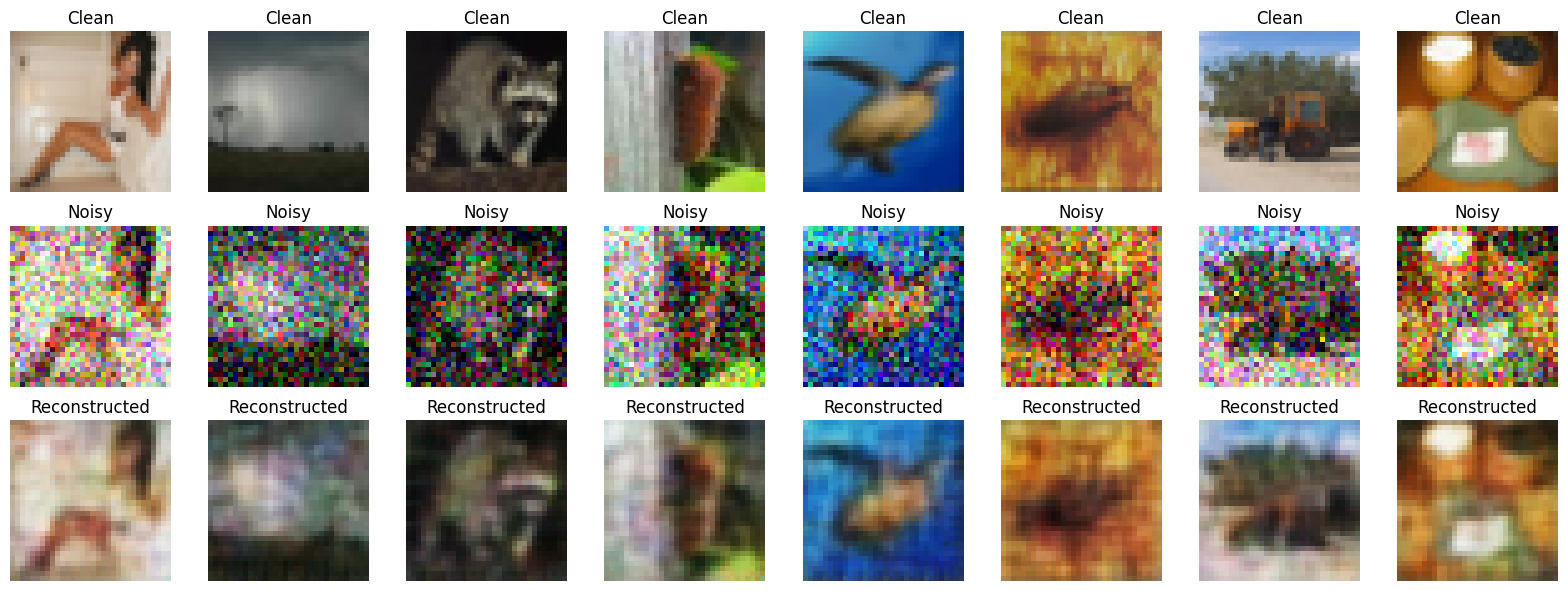

In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 8, figsize=(16, 6))
for i in range(8):
    axes[0, i].imshow(clean_images[i].cpu().permute(1, 2, 0))
    axes[0, i].axis("off")
    axes[0, i].set_title("Clean")

    axes[1, i].imshow(noisy_images[i].cpu().permute(1, 2, 0))
    axes[1, i].axis("off")
    axes[1, i].set_title("Noisy")

    axes[2, i].imshow(reconstructions[i].cpu().permute(1, 2, 0))
    axes[2, i].axis("off")
    axes[2, i].set_title("Reconstructed")
plt.tight_layout()
plt.show()